# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from pathlib import Path
import os
import hashlib
from tensorflow.keras import models, layers
from sklearn.utils.class_weight import compute_class_weight


# Loading the dataset

In [2]:
DATA_DIR = r'C:\Users\AK\source\repos\Garbage-image-model-classification\garbage_classification'

class_names = []
for item in os.listdir(DATA_DIR):
    full_path = os.path.join(DATA_DIR, item)
    if os.path.isdir(full_path):
        class_names.append(item)

class_names = sorted(class_names)

print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

Number of classes: 12
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


Counting the number of images in each class folder to check for class balance.

In [3]:
class_counts = {}
for class_name in class_names:
    class_folder = os.path.join(DATA_DIR, class_name)
    num_images = len(os.listdir(class_folder))
    class_counts[class_name] = num_images

for class_name, count in class_counts.items():
    print(f"{class_name:15s} {count}")

print(f"\nTotal images: {sum(class_counts.values())}")

battery         945
biological      985
brown-glass     607
cardboard       891
clothes         5325
green-glass     629
metal           769
paper           1050
plastic         865
shoes           1977
trash           697
white-glass     775

Total images: 15515


Building a metadata table (Df) with one row per image. Columns: filepath, class, width, height, mode, filesize. This gives us a tabular view of the dataset so pandas can be used for EDA on image properties.

In [4]:
records = []

for class_name in class_names:
    class_folder = os.path.join(DATA_DIR, class_name)
    for filename in os.listdir(class_folder):
        filepath = os.path.join(class_folder, filename)
        try:
            with Image.open(filepath) as img:
                width, height = img.size
                mode = img.mode
            filesize = os.path.getsize(filepath)
            records.append({
                'filepath': filepath,
                'class': class_name,
                'width': width,
                'height': height,
                'mode': mode,
                'filesize': filesize
            })
        except Exception as e:
            print(f"Could not read {filepath}: {e}")

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
df.sample(20)

DataFrame shape: (15515, 6)


,filepath,class,width,height,mode,filesize
7380,C:\Users\AK\source\repos\Garbage-image-model-c...,clothes,400,533,RGB,18266
1833,C:\Users\AK\source\repos\Garbage-image-model-c...,biological,275,183,RGB,3730
141,C:\Users\AK\source\repos\Garbage-image-model-c...,battery,225,225,RGB,8122
6415,C:\Users\AK\source\repos\Garbage-image-model-c...,clothes,400,534,RGB,21743
11691,C:\Users\AK\source\repos\Garbage-image-model-c...,plastic,225,225,RGB,4330
4631,C:\Users\AK\source\repos\Garbage-image-model-c...,clothes,400,533,RGB,38901
3083,C:\Users\AK\source\repos\Garbage-image-model-c...,cardboard,259,194,RGB,3487
3021,C:\Users\AK\source\repos\Garbage-image-model-c...,cardboard,210,210,RGB,5166
11506,C:\Users\AK\source\repos\Garbage-image-model-c...,plastic,512,384,RGB,12683
1978,C:\Users\AK\source\repos\Garbage-image-model-c...,brown-glass,259,195,RGB,3866


Quick inspection of the metadata DataFrame: data types, basic statistics, and a check for any missing values.

In [5]:
df.dtypes

filepath      str
class         str
width       int64
height      int64
mode          str
filesize    int64
dtype: object

In [6]:
df.isnull().sum()

filepath    0
class       0
width       0
height      0
mode        0
filesize    0
dtype: int64

In [7]:
df.describe()

,width,height,filesize
count,15515.000000,15515.000000,15515.000000
mean,349.822301,351.705833,16146.196197
std,117.548544,149.418487,12385.249040
min,51.000000,100.000000,1073.000000
25%,234.000000,224.000000,5944.000000
50%,400.000000,384.000000,13071.000000
75%,400.000000,533.000000,23259.000000
max,888.000000,936.000000,87712.000000


## Exploratory Data Analysis


Counting images per class to check whether the dataset is balanced.

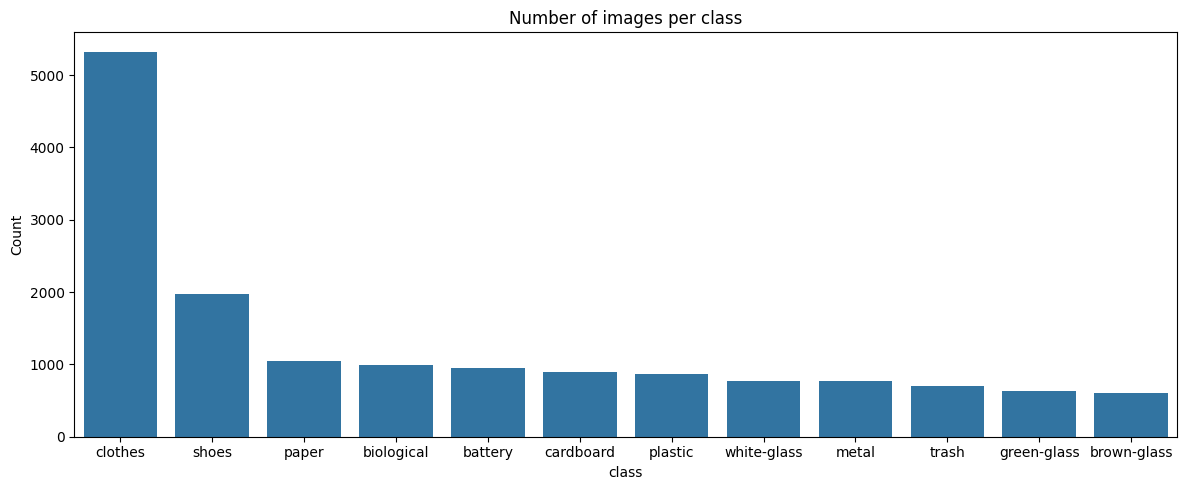

class
clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607
Name: count, dtype: int64

In [8]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title('Number of images per class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['class'].value_counts()

### Sample images per class

Displaying 16 random images from each class to visually inspect what the data looks like.

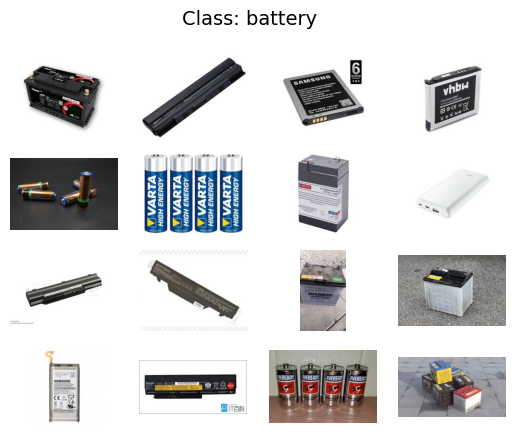

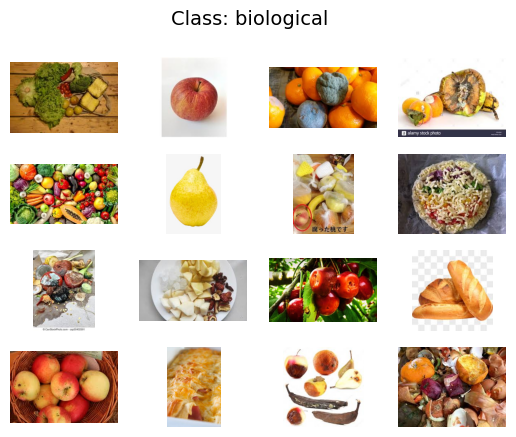

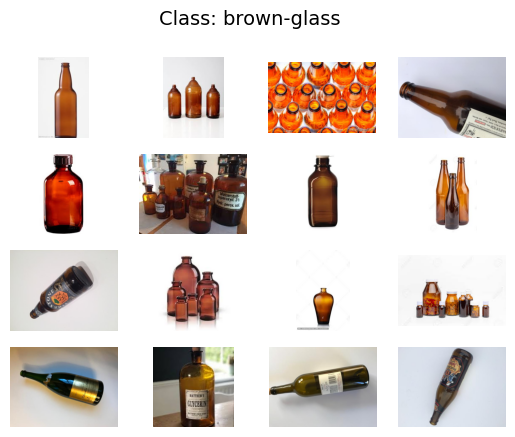

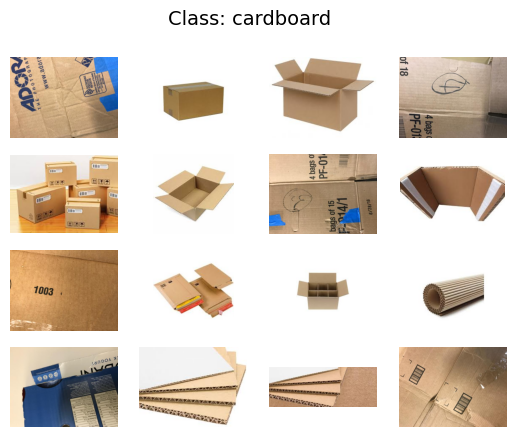

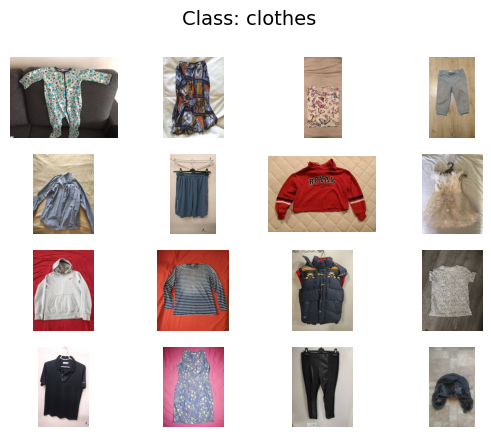

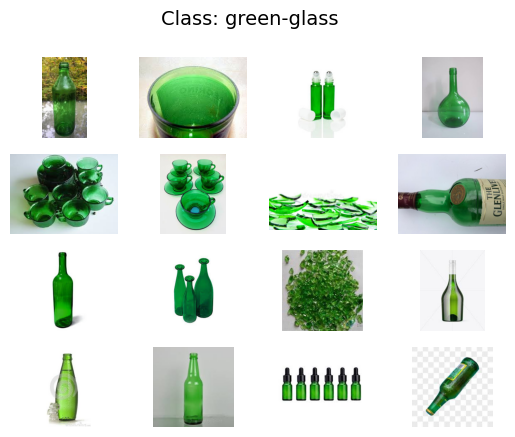

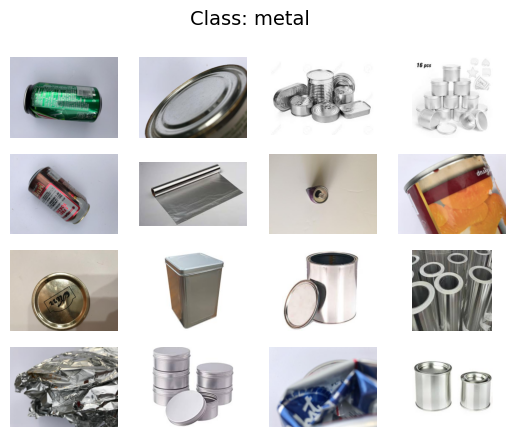

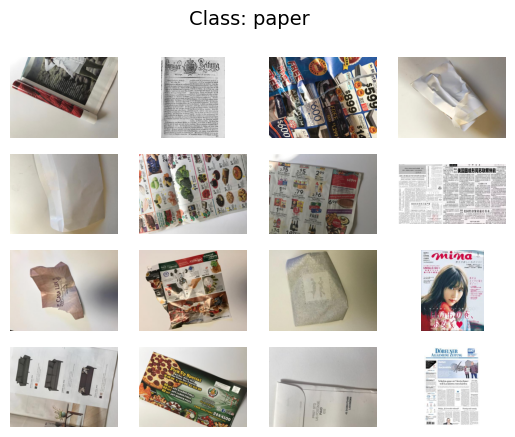

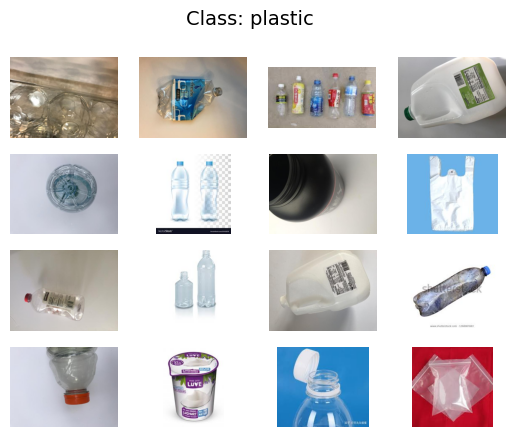

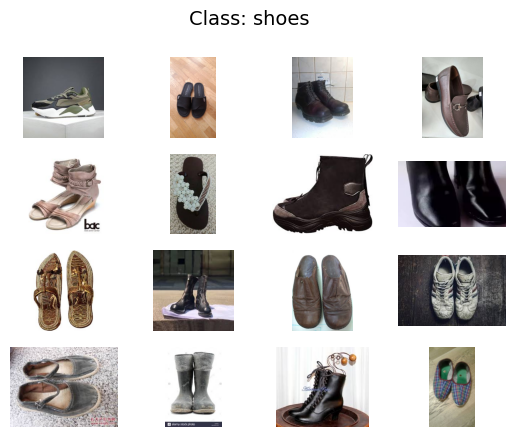

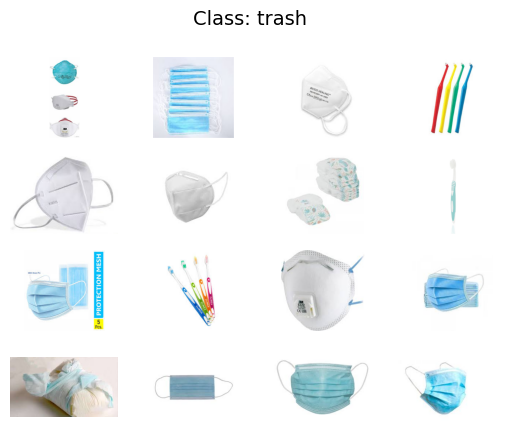

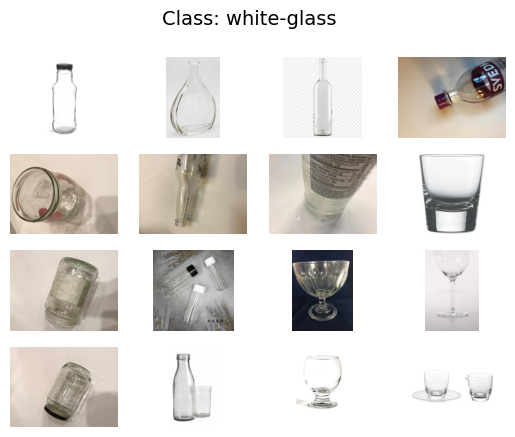

In [9]:
SAMPLES_PER_CLASS = 16

for class_name in class_names:
    class_df = df[df['class'] == class_name]
    samples = class_df.sample(n=SAMPLES_PER_CLASS, random_state=40)
    filepaths = samples['filepath'].tolist()

    fig, axes = plt.subplots(4, 4)
    fig.suptitle(f"Class: {class_name}", fontsize=14)

    i = 0
    for row in range(4):
        for col in range(4):
            img = Image.open(filepaths[i])
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            i = i + 1
    plt.show()

### Observations from inspection

- Green glass is the only visually consistent class - defined almost entirely by its green colour.
- Trash is poorly defined in the source data - it consists almost entirely of disposable masks, toothbrushes and diapers rather than general trash. 
- All other classes show high variation in shape, size, and colour. This is expected and reflects real world data.

## Histograms
Visualising the width and height distributions of all images in the dataset. Histograms show where image sizes cluster.

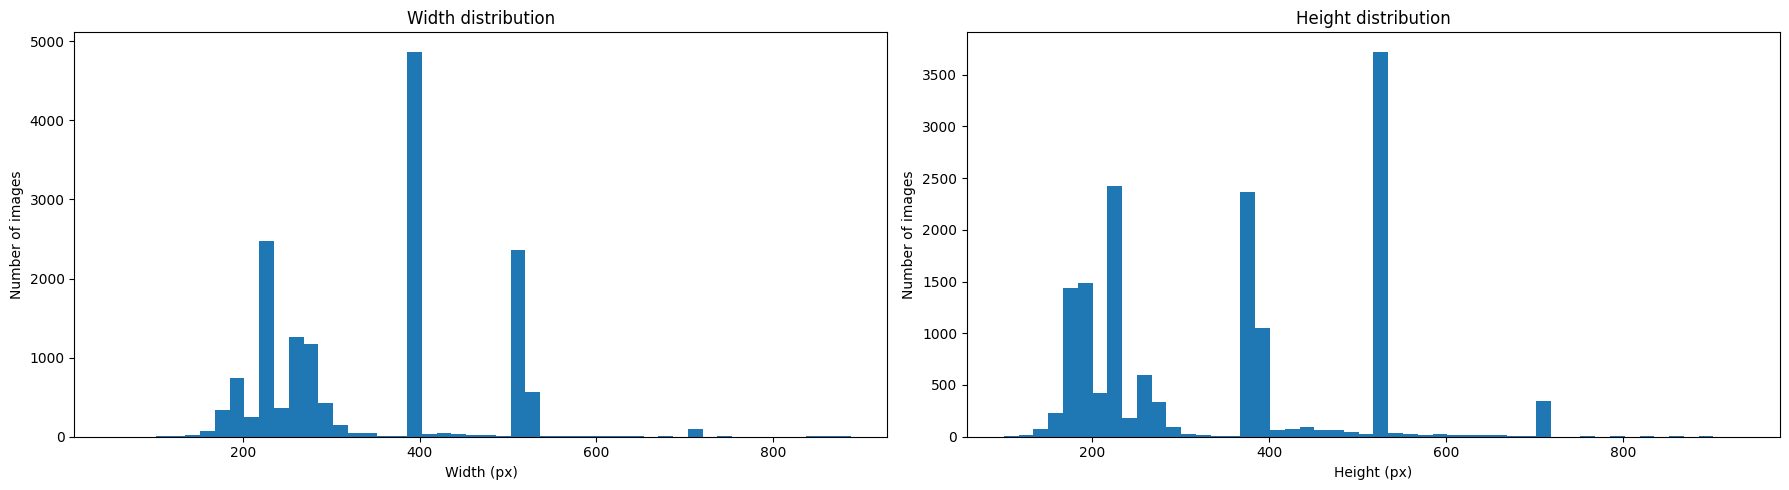

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].hist(df['width'], bins=50)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Width distribution')

axes[1].hist(df['height'], bins=50)
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Number of images')
axes[1].set_title('Height distribution')

plt.tight_layout()
plt.show()

The dataset is overwhelmingly RGB 

In [11]:
df['mode'].value_counts()

mode
RGB    15481
P         34
Name: count, dtype: int64

### 3.5 Filesize distribution

Looking at the distribution of filesize across all images. The aim is to spot unusually tiny files (likely corrupted) or unusually large ones (likely outliers worth investigating).

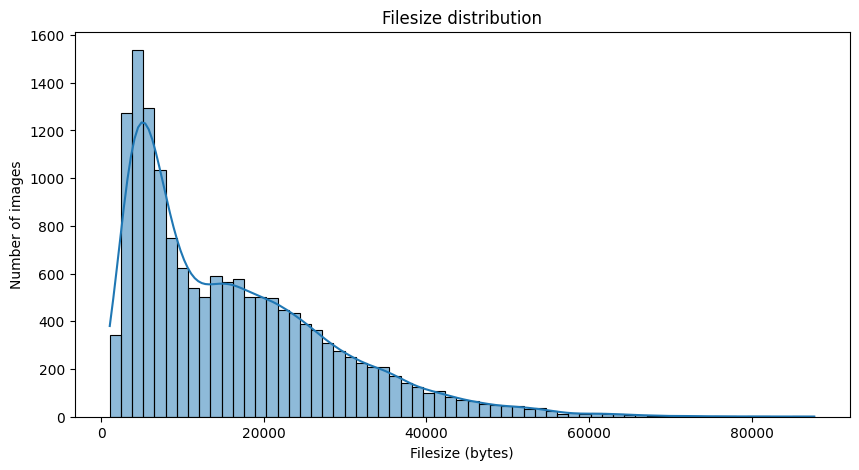

In [12]:
plt.figure(figsize=(10, 5))
# plt.hist(df['filesize'], bins=50)
sns.histplot(data=df['filesize'], kde=True)
plt.xlabel('Filesize (bytes)')
plt.ylabel('Number of images')
plt.title('Filesize distribution')
plt.show()

## Summary of EDA findings

- **Class distribution is severely imbalanced.** The largest class, clothes has 5,325 images while the smallest class brown-glass has 607 images. This will be addressed with `class_weight='balanced'` during training and/or with stratified splitting.

- **Visual inspection of sample images** revealed that green-glass is the only visually consistent class, defined primarily by its colour. The 'trash' class  consists almost entirely of medical masks and toothbrushes rather than general trash. Other classes show variation in shape, size, and colour, which is expected for real world data but means some classes (e.g. battery, with both small battery cells and big car batteries) may be hard to learn at low input resolutions.

- **Image dimensions** most images are around 400–500 px in both width and height. The histograms show sharp peaks in areas 300px - 500 px.

## Section 4 - Data cleaning


Looping through every image and attempting to fully load it with PIL. Files that fail to load (e.g corrupted files) are flagged for removal.

In [13]:
bad_files = []

for i in range(len(df)):
    filepath = df.iloc[i]['filepath']
    try:
        with Image.open(filepath) as img:
            img.verify()
    except Exception as e:
        bad_files.append(filepath)
        print(f"Bad file: {filepath} — {e}")

print(f"\nTotal corrupted files found: {len(bad_files)}")


Total corrupted files found: 0


No corrupted files were detected - all 15,515 images verified successfully.

### Drop non-RGB images

EDA identified 34 images in palette ('P') mode rather than RGB. These are removed here so every image in the pipeline has a consistent 3-channel structure.


In [14]:
rows_before = len(df)
df = df[df['mode'] == 'RGB']
rows_after = len(df)

print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Removed:     {rows_before - rows_after}")

Rows before: 15515
Rows after:  15481
Removed:     34


### Remove exact duplicates

Computing an md5 hash for each file's raw bytes. Files with matching hashes are byte-for-byte identical and indicate the same image is present in the dataset more than once. Exact duplicates can cause data leakage if they end up split across train and test sets.

In [15]:


def compute_md5(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['md5'] = df['filepath'].apply(compute_md5)
df.head()

,filepath,class,width,height,mode,filesize,md5
0,C:\Users\AK\source\repos\Garbage-image-model-c...,battery,280,180,RGB,7405,f97a23ebb921020ce0dc8c5eb92234d0
1,C:\Users\AK\source\repos\Garbage-image-model-c...,battery,220,165,RGB,4900,9f851944fa3f3b4d4c4fd1ccab8d7045
2,C:\Users\AK\source\repos\Garbage-image-model-c...,battery,275,183,RGB,12976,46c1b57f1fa6df6ae0484651358e3c25
3,C:\Users\AK\source\repos\Garbage-image-model-c...,battery,275,183,RGB,9825,e0e7a6d10f02ed74f41f156631c61a33
4,C:\Users\AK\source\repos\Garbage-image-model-c...,battery,224,224,RGB,3111,9bab566b0bd52315838818f03e190976


In [16]:
rows_before = len(df)
duplicate_count = df['md5'].duplicated().sum()
print(f"Exact duplicates found: {duplicate_count}")

df = df.drop_duplicates(subset='md5', keep='first').reset_index(drop=True)
rows_after = len(df)
print(f"\nRows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Removed:     {rows_before - rows_after}")

Exact duplicates found: 19

Rows before: 15481
Rows after:  15462
Removed:     19


19 exact duplicates (byte identical files) were identified via md5 hashing and removed. 

## Section 5 - Preprocessing ##

Converting the cleaned Dataframe into the format the CNN expects: a numpy array of  pixel values paired with integer-encoded labels, split into train, validation, and test sets.

for our first iteration well have the target image size (64x64 px). it is small enough to train on CPU in reasonable time, large enough to retain shape and colour features. If model accuracy proves insufficient, this can be increased to 128×128.

In [17]:
IMG_SIZE = 64

### Load, resize, and stack images into a numpy array

Each image is opened with PIL, resized to 64×64, converted to a numpy array, and stacked into one large 4D array of shape (n amount of images, 64, 64, 3). This is the format the CNN expects.

In [18]:
images = []
labels = []

for i in range(len(df)):
    filepath = df.iloc[i]['filepath']
    class_name = df.iloc[i]['class']

    img = Image.open(filepath)
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img)

    images.append(img_array)
    labels.append(class_name)

X = np.array(images)
y = np.array(labels)
X = X.astype('float32') / 255.0

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"min: {X.min()}, max: {X.max()}, dtype: {X.dtype}")
print(X[0, 0, 0])  # the first pixel of the first image — three numbers (R, G, B)

X shape: (15462, 64, 64, 3)
y shape: (15462,)
min: 0.0, max: 1.0, dtype: float32
[0.80784315 0.78039217 0.7411765 ]


### Label encoding

Converting class names from strings to integers using `LabelEncoder`. This produces aт array of integers (0–11) matching the 12 classes. The integer-encoding choice pairs with `sparse_categorical_crossentropy` as the loss function later in Section 6. (remove this)

In [19]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Class integer mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i:2d} - {class_name}")


Class integer mapping:
   0 - battery
   1 - biological
   2 - brown-glass
   3 - cardboard
   4 - clothes
   5 - green-glass
   6 - metal
   7 - paper
   8 - plastic
   9 - shoes
  10 - trash
  11 - white-glass


### 5.5 Train / validation / test split

Splitting the dataset 70/15/15 into training, validation, and test sets. Stratification preserves class proportions in each subset, which matters here because the dataset is severely imbalanced. The split is done in two `train_test_split` calls — the first separates out the test set, the second splits the remaining 85% into train and validation.

In [20]:
RANDOM_STATE = 40

# First split - separate out the test set (15% of total)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded,
    test_size=0.15,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

# Second split - split the remaining 85% into train (~70%) and val (~15%)
# 0.15 / 0.85 ≈ 0.1765 - this gives val ≈ 15% of the original total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    stratify=y_trainval,
    random_state=RANDOM_STATE
)

print(f"Training set:   {X_train.shape}, labels: {y_train.shape}")
print(f"Validation set: {X_val.shape}, labels: {y_val.shape}")
print(f"Test set:       {X_test.shape}, labels: {y_test.shape}")


Training set:   (10822, 64, 64, 3), labels: (10822,)
Validation set: (2320, 64, 64, 3), labels: (2320,)
Test set:       (2320, 64, 64, 3), labels: (2320,)


### Model summary

three Conv2D layers, each followed by a MaxPooling layer. The Conv2D layers detect patterns in the image, starting with simple ones like edges and colours, and building up to more complex shapes and object parts. Each MaxPooling layer shrinks the image down, making the network smaller and faster, and less fussy about exactly where in the image a pattern appears.


In [21]:

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), #to do experiment with this during training to see if it helps with overfitting
    layers.Dense(12, activation='softmax')
])

model.summary()

c:\Users\AK\source\repos\Garbage-image-model-classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,748 (2.61 MB)

 Trainable params: 684,748 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

6.2 enter summary here

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.3726534753932014), 1: np.float64(1.3089017900338655), 2: np.float64(2.1219607843137256), 3: np.float64(1.4475655430711611), 4: np.float64(0.24203793165145823), 5: np.float64(2.0972868217054264), 6: np.float64(1.673160173160173), 7: np.float64(1.230331969076853), 8: np.float64(1.490633608815427), 9: np.float64(0.6516136801541426), 10: np.float64(1.9147204529370134), 11: np.float64(1.6700617283950616)}


In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3263 - loss: 1.9325 - val_accuracy: 0.4401 - val_loss: 1.6902
Epoch 2/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4883 - loss: 1.5517 - val_accuracy: 0.5776 - val_loss: 1.2950
Epoch 3/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5485 - loss: 1.3970 - val_accuracy: 0.5720 - val_loss: 1.3292
Epoch 4/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5963 - loss: 1.2593 - val_accuracy: 0.6599 - val_loss: 1.0523
Epoch 5/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6417 - loss: 1.1218 - val_accuracy: 0.6297 - val_loss: 1.1101
Epoch 6/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6680 - loss: 1.0508 - val_accuracy: 0.6366 - val_loss: 1.1433
Epoch 7/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6991 - loss: 0.9445 - val_accuracy: 0.7065 - val_loss: 0.9515
Epoch 8/15
339/339 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7252 - loss: 0.8614 - val_accu

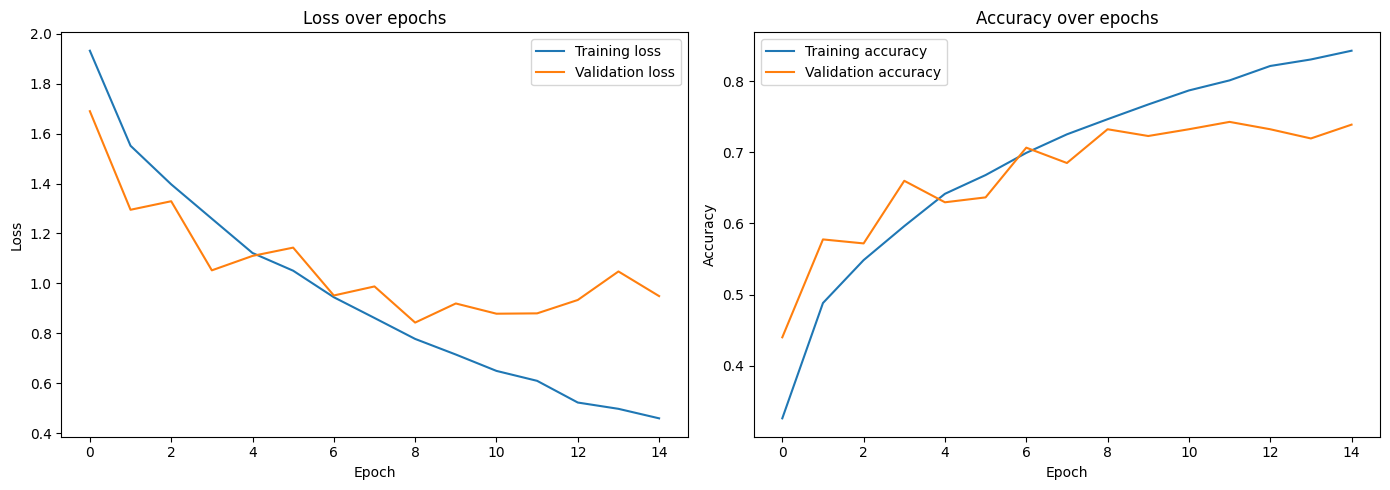

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()

# Accuracy curves
axes[1].plot(history.history['accuracy'], label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Predictions on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

Test loss:     0.9329
Test accuracy: 0.7556
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [28]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

     battery       0.75      0.70      0.72       141
  biological       0.69      0.82      0.75       148
 brown-glass       0.80      0.82      0.81        91
   cardboard       0.61      0.82      0.70       134
     clothes       0.93      0.87      0.90       799
 green-glass       0.88      0.91      0.89        92
       metal       0.44      0.48      0.46       115
       paper       0.58      0.69      0.63       157
     plastic       0.70      0.49      0.58       130
       shoes       0.74      0.68      0.71       296
       trash       0.65      0.75      0.70       101
 white-glass       0.63      0.56      0.59       116

    accuracy                           0.76      2320
   macro avg       0.70      0.72      0.70      2320
weighted avg       0.77      0.76      0.76      2320

